## Import libraries

In [1]:
# Setup and Imports
from pathlib import Path
import os, sys

project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))
os.chdir(project_root)

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

from fmu2ml.data.processors import (
    NormalizationHandler,
    DatacenterCoolingDataset,
    SingleChunkSplitDataset,
    create_data_loaders,
    DataValidator,
    ValidationLevel,
    PhysicsValidator
)
from fmu2ml.config import ModelConfig, TrainingConfig
from raps.config import ConfigManager

sns.set_style("whitegrid")
%matplotlib inline

print("✓ Imports complete")

✓ Imports complete


In [2]:
# Configuration
SYSTEM_NAME = 'summit'
config = ConfigManager(system_name=SYSTEM_NAME).get_config()

# Data paths
DATA_PATH = f'../{SYSTEM_NAME}/data/systematic'
CHUNK_TO_TEST = None
OUTPUT_DIR = f'../results/{SYSTEM_NAME}/data_processing_tests'

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# System parameters
NUM_CDUS = config['NUM_CDUS']
SEQUENCE_LENGTH = 20
BATCH_SIZE = 64
NUM_WORKERS = 48

print(f"System: {SYSTEM_NAME}")
print(f"Number of CDUs: {NUM_CDUS}")
print(f"Data path: {DATA_PATH}")
print(f"Test chunk: {CHUNK_TO_TEST}")
print(f"Sequence length: {SEQUENCE_LENGTH}")
print(f"Output directory: {OUTPUT_DIR}")

System: summit
Number of CDUs: 257
Data path: ../summit/data/systematic
Test chunk: None
Sequence length: 20
Output directory: ../results/summit/data_processing_tests


In [3]:
# Load Raw Data for Inspection
print("="*80)
print("LOADING RAW DATA")
print("="*80)



chunk_path = (Path(DATA_PATH) / f"chunk_{CHUNK_TO_TEST}" ) if CHUNK_TO_TEST else Path(DATA_PATH)
parquet_files = list(chunk_path.glob("*_output_*.parquet"))

if not parquet_files:
    parquet_files = list(chunk_path.glob("*.parquet"))

if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {chunk_path}")

parquet_file = parquet_files[0]
print(f"Loading: {parquet_file}")

df = pd.read_parquet(parquet_file)

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"Samples: {len(df)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

# Display first few rows
display(Markdown("### First 5 rows"))
display(df.head())

LOADING RAW DATA
Loading: ../summit/data/systematic/systematic_fmu_output_25hrs.parquet

Dataset shape: (93584, 6430)
Columns: 6430
Samples: 93584
Memory usage: 4813.96 MB


### First 5 rows

,simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_4_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_7_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_8_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_9_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_10_cabinet_1_sources_Q_flow_total,...,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_prim_s,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_prim_s_psig,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_prim_r,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_prim_r_psig,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_sec_s,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_sec_s_psig,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_sec_r,simulator[1].datacenter[1].computeBlock[257].cdu[1].summary.p_sec_r_psig,simulator[1].datacenter[1].computeBlock[257].cabinet[1].summary.htc,pue
0,45134.397717,31215.237181,41768.006901,23394.070135,28554.248465,31516.582879,21251.054355,31687.229346,26187.160991,42642.480191,...,541843.609179,64.083998,528865.125618,62.201628,304856.568651,29.711933,104856.569352,0.704386,50.0,1.129555
1,45108.743768,31215.237181,41739.926353,23386.545580,28593.236464,31516.582879,21312.327375,31687.229346,26187.061837,42642.480191,...,541846.411906,64.084404,528867.944418,62.202036,304856.538534,29.711929,104856.539235,0.704381,50.0,1.129535
2,45117.247974,31215.237181,41711.730395,23379.021024,28671.807336,31516.582879,21281.517229,31687.229346,26164.826881,42642.480191,...,541849.214206,64.084810,528870.762787,62.202445,304856.598499,29.711938,104856.599200,0.704390,50.0,1.129551
3,45233.642823,31215.237181,41683.419372,23371.496469,28648.573597,31516.582879,21280.911335,31687.229346,26080.712512,42642.480191,...,541852.016075,64.085217,528873.580722,62.202854,304856.644955,29.711944,104856.645656,0.704397,50.0,1.129536
4,45175.922035,31215.237181,41654.993628,23363.971914,28596.830529,31516.582879,21310.631944,31687.229346,26060.413661,42642.480191,...,541854.817515,64.085623,528876.398226,62.203263,304856.490399,29.711922,104856.491100,0.704374,50.0,1.129561


In [4]:
# Inspect Column Structure
print("="*80)
print("COLUMN STRUCTURE ANALYSIS")
print("="*80)

# Categorize columns
input_cols = []
output_cols = []
other_cols = []

for col in df.columns:
    if 'sources_Q_flow_total' in col or 'sources_T_Air' in col or 'sources_T_ext' in col:
        input_cols.append(col)
    elif 'cdu[1].summary' in col or 'datacenter[1].summary' in col or 'htc' in col or col == 'pue':
        output_cols.append(col)
    else:
        other_cols.append(col)

print(f"\nInput columns: {len(input_cols)}")
print(f"Output columns: {len(output_cols)}")
print(f"Other columns: {len(other_cols)}")

# Display column samples
display(Markdown("### Sample Input Columns"))
for col in input_cols[:5]:
    print(f"  - {col}")
if len(input_cols) > 5:
    print(f"  ... and {len(input_cols) - 5} more")

display(Markdown("### Sample Output Columns"))
for col in output_cols[:10]:
    print(f"  - {col}")
if len(output_cols) > 10:
    print(f"  ... and {len(output_cols) - 10} more")

COLUMN STRUCTURE ANALYSIS

Input columns: 515
Output columns: 5914
Other columns: 1


### Sample Input Columns

  - simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_Q_flow_total
  - simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_Q_flow_total
  - simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_Q_flow_total
  - simulator_1_datacenter_1_computeBlock_4_cabinet_1_sources_Q_flow_total
  - simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_Q_flow_total
  ... and 510 more


### Sample Output Columns

  - simulator[1].datacenter[1].summary.m_flow_prim
  - simulator[1].datacenter[1].summary.V_flow_prim_GPM
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_prim
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_prim_GPM
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_sec
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_sec_GPM
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP_kW
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C
  ... and 5904 more


In [5]:
# Basic Data Statistics
print("="*80)
print("DATA STATISTICS")
print("="*80)

# Input statistics
print("\n### INPUT STATISTICS")
input_df = df[input_cols]

display(Markdown("#### Power Inputs (Q_flow_total)"))
power_cols = [col for col in input_cols if 'Q_flow_total' in col]
power_stats = df[power_cols].describe()
display(power_stats)

display(Markdown("#### Air Temperature Inputs (T_Air - Kelvin)"))
air_temp_cols = [col for col in input_cols if 'T_Air' in col]
air_temp_stats = df[air_temp_cols].describe()
display(air_temp_stats)

display(Markdown("#### External Temperature (T_ext - Kelvin)"))
ext_temp_col = [col for col in input_cols if 'T_ext' in col]
if ext_temp_col:
    ext_temp_stats = df[ext_temp_col].describe()
    display(ext_temp_stats)

# Output statistics
print("\n### OUTPUT STATISTICS")

display(Markdown("#### Primary Flow Rates (GPM)"))
prim_flow_cols = [col for col in output_cols if 'V_flow_prim_GPM' in col][:5]
if prim_flow_cols:
    display(df[prim_flow_cols].describe())

display(Markdown("#### Temperatures (Celsius)"))
temp_output_cols = [col for col in output_cols if 'T_prim_s_C' in col or 'T_prim_r_C' in col][:5]
if temp_output_cols:
    display(df[temp_output_cols].describe())

display(Markdown("#### PUE"))
if 'pue' in df.columns:
    display(df[['pue']].describe())

DATA STATISTICS

### INPUT STATISTICS


#### Power Inputs (Q_flow_total)

,simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_4_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_7_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_8_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_9_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_10_cabinet_1_sources_Q_flow_total,...,simulator_1_datacenter_1_computeBlock_248_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_249_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_250_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_251_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_252_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_253_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_254_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_255_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_256_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_257_cabinet_1_sources_Q_flow_total
count,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,...,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000
mean,31895.624282,32078.077070,31638.029058,29718.313911,30955.111264,34433.419113,30829.268038,33141.093753,29665.328805,32177.092322,...,31657.529217,34430.928606,32467.962130,30596.739322,30535.597405,32383.907292,33599.679317,32629.054330,30906.706544,33207.674383
std,7106.380180,7060.850180,7544.751537,6795.229183,7309.208269,7775.876158,7007.010623,6934.466608,7438.726464,6559.899422,...,7791.999817,7715.476006,6684.156238,6430.421682,5719.421550,6637.868009,7286.267554,6587.533210,7038.552554,7422.006851
min,15216.305469,17175.859752,15613.136850,15421.986749,15442.302140,18899.533995,14993.388342,17435.568534,14680.201273,17512.705643,...,17208.567534,17287.120032,15448.378025,15097.808886,14829.848966,15683.860365,18120.216670,16081.652350,14931.300647,16242.552292
25%,26355.856352,25965.383622,26017.772518,25035.180613,25986.423100,27761.758785,25230.987558,27522.819783,24570.535222,28301.189766,...,26148.259814,29144.097580,27754.692582,25806.220441,25949.546542,28981.059633,27676.241192,28514.886724,25126.505913,28174.306283
50%,31468.485329,31282.198490,31604.289143,27847.185240,30629.228195,34051.530684,30349.787166,32154.338953,29333.663158,31886.512372,...,31453.153321,33262.006661,33339.366852,30561.156419,30445.913108,31747.448486,32931.502079,32526.984544,30224.108547,32878.359037
75%,36726.704436,37138.134838,37286.216642,34660.797182,36530.544060,40707.416852,36140.185620,37031.602150,34727.706695,37264.496281,...,36758.046828,38871.981641,36544.917266,35660.691936,33721.570304,36412.048700,38513.554622,38043.000608,36181.107686,39001.883876
max,48511.576294,47811.461129,50002.586657,47044.504681,48033.373779,51528.933803,47146.808689,50742.745832,46422.084858,49202.797955,...,49250.113606,51961.923261,49398.391961,48791.846907,46895.304383,49595.879731,49594.198164,49023.674738,47062.042976,49248.456558


#### Air Temperature Inputs (T_Air - Kelvin)

,simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_4_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_7_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_8_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_9_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_10_cabinet_1_sources_T_Air,...,simulator_1_datacenter_1_computeBlock_248_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_249_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_250_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_251_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_252_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_253_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_254_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_255_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_256_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_257_cabinet_1_sources_T_Air
count,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,...,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000
mean,298.359900,297.955080,298.362437,298.241595,298.179070,298.370150,298.081852,298.091024,297.854783,298.143683,...,298.259306,297.956493,298.213842,298.171754,298.526228,298.343221,298.110389,298.472189,298.486869,298.001697
std,2.813251,1.692606,2.487161,1.829254,2.401132,2.700152,1.888946,2.493946,1.952489,1.805257,...,2.148571,2.165532,2.236813,2.448670,2.644905,2.236096,1.868126,3.138626,2.271494,1.578645
min,291.428415,291.666519,293.931552,293.184387,291.627987,291.453732,294.696559,291.906699,293.074833,293.010052,...,291.991426,293.821944,292.272038,292.045514,291.858227,293.356927,294.437998,293.579896,294.235620,294.023183
25%,297.137915,296.699422,296.832648,296.975469,296.721547,296.966973,296.759752,296.679724,296.204606,297.139147,...,296.850366,296.331841,296.877084,296.852904,297.211348,296.844180,296.913850,296.792255,297.256129,296.900835
50%,297.818611,297.726775,298.040127,298.232313,297.675119,298.003610,297.863432,297.655524,297.725168,298.028207,...,298.072764,297.873742,298.009918,297.931094,298.305178,298.162299,297.973534,297.981651,298.066723,297.889436
75%,298.977079,298.853000,298.902078,299.421441,298.918233,299.153959,298.822188,298.783540,298.903926,298.885988,...,299.366008,298.896418,298.955860,298.755381,298.908846,299.204146,298.907714,299.075375,299.301828,298.895630
max,313.707366,306.269123,313.364613,310.226666,314.438805,313.856745,313.118478,312.958178,307.892419,311.046657,...,313.139406,309.453762,312.951460,311.216735,313.636776,314.208815,311.508798,312.786975,313.554260,308.713376


...

,simulator[1].datacenter[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[3].cdu[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[4].cdu[1].summary.V_flow_prim_GPM
count,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000
mean,5309.059889,20.657398,20.657302,20.657415,20.657272
std,13.609000,0.053010,0.053080,0.052572,0.053088
min,5281.168238,20.545911,20.546400,20.545903,20.545762
25%,5299.062219,20.618227,20.617860,20.618168,20.618186
50%,5308.153369,20.654356,20.654833,20.654490,20.653735
75%,5317.765783,20.690558,20.692105,20.690947,20.690206
max,5346.230475,20.807352,20.811432,20.802511,20.810917


#### Temperatures (Celsius)

,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_r_C,simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_prim_s_C,simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_prim_r_C,simulator[1].datacenter[1].computeBlock[3].cdu[1].summary.T_prim_s_C
count,93584.000000,93584.000000,93584.000000,93584.000000,93584.000000
mean,40.139388,45.391536,40.139384,45.379753,40.139383
std,2.710485,2.268385,2.710485,2.254293,2.710484
min,33.353016,39.037226,33.353005,39.460162,33.353022
25%,38.322061,43.815136,38.322029,43.872394,38.322125
50%,40.223063,45.398619,40.223061,45.529262,40.223054
75%,42.194569,46.972853,42.194569,47.086698,42.194569
max,45.569878,50.370485,45.569837,49.993752,45.569844


#### PUE

,pue
count,93584.000000
mean,1.131017
std,0.001799
min,1.125401
25%,1.129822
50%,1.130991
75%,1.132164
max,1.137826


DATA DISTRIBUTION VISUALIZATIONS


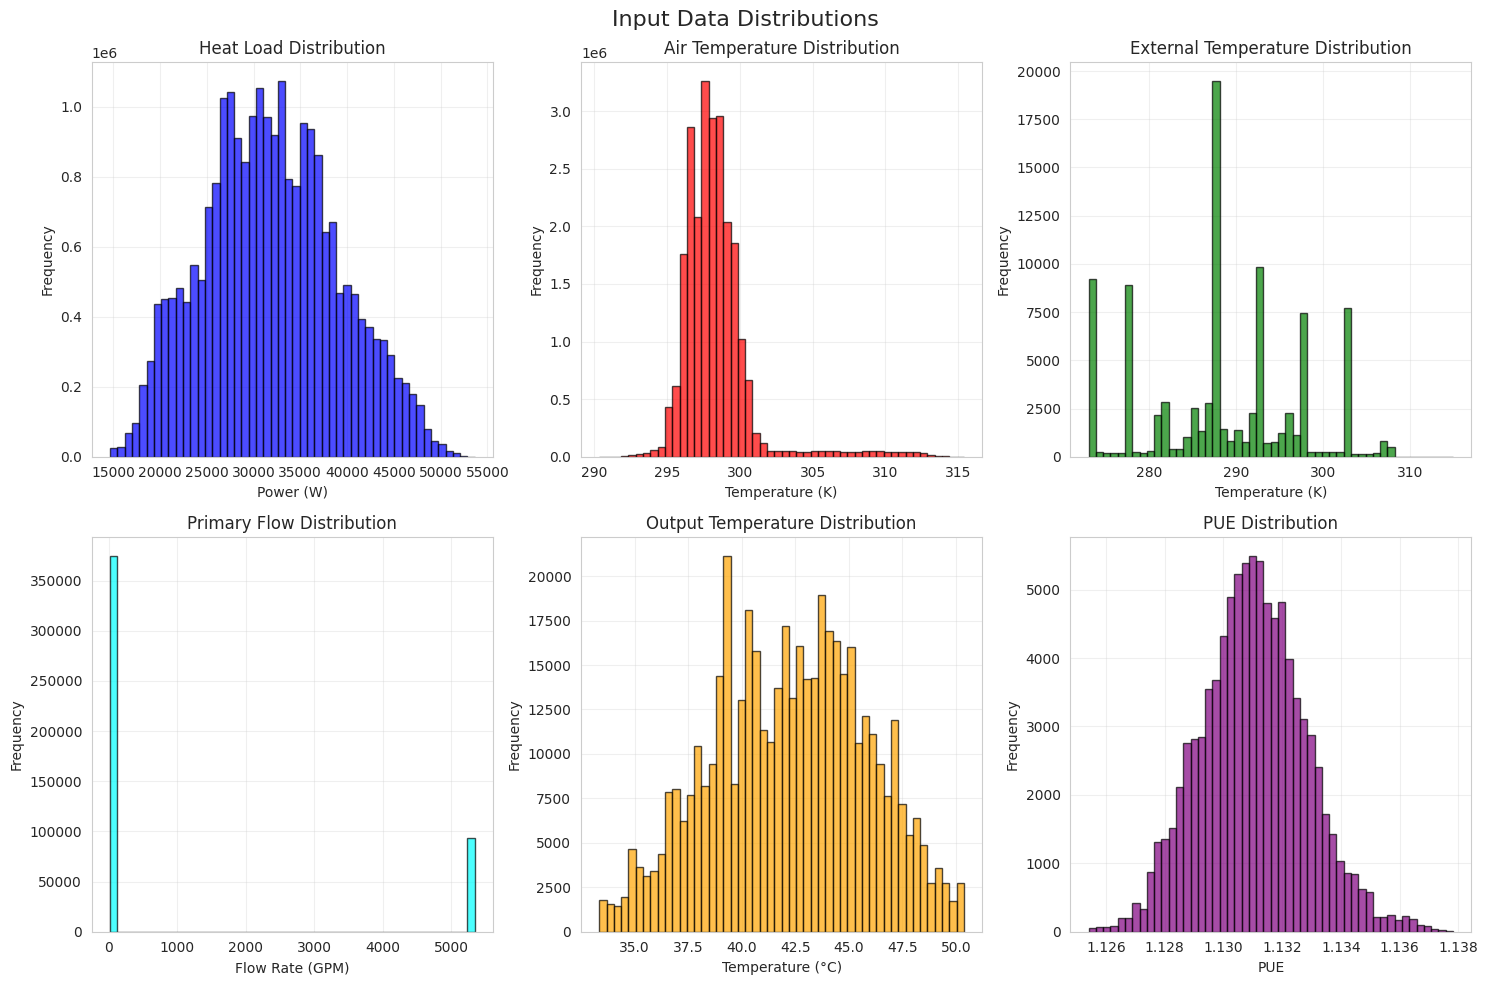

✓ Saved to ../results/summit/data_processing_tests/data_distributions.png


In [6]:
# Visualize Data Distributions
print("="*80)
print("DATA DISTRIBUTION VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Input Data Distributions', fontsize=16)

# Power distribution
ax = axes[0, 0]
power_data = df[power_cols].values.flatten()
ax.hist(power_data, bins=50, alpha=0.7, color='blue', edgecolor='black')
ax.set_xlabel('Power (W)')
ax.set_ylabel('Frequency')
ax.set_title('Heat Load Distribution')
ax.grid(True, alpha=0.3)

# Air temperature distribution
ax = axes[0, 1]
air_temp_data = df[air_temp_cols].values.flatten()
ax.hist(air_temp_data, bins=50, alpha=0.7, color='red', edgecolor='black')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Frequency')
ax.set_title('Air Temperature Distribution')
ax.grid(True, alpha=0.3)

# External temperature distribution
ax = axes[0, 2]
if ext_temp_col:
    ext_temp_data = df[ext_temp_col[0]].values
    ax.hist(ext_temp_data, bins=50, alpha=0.7, color='green', edgecolor='black')
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Frequency')
    ax.set_title('External Temperature Distribution')
    ax.grid(True, alpha=0.3)

# Flow rate distribution
ax = axes[1, 0]
if prim_flow_cols:
    flow_data = df[prim_flow_cols].values.flatten()
    ax.hist(flow_data, bins=50, alpha=0.7, color='cyan', edgecolor='black')
    ax.set_xlabel('Flow Rate (GPM)')
    ax.set_ylabel('Frequency')
    ax.set_title('Primary Flow Distribution')
    ax.grid(True, alpha=0.3)

# Temperature output distribution
ax = axes[1, 1]
if temp_output_cols:
    temp_out_data = df[temp_output_cols].values.flatten()
    ax.hist(temp_out_data, bins=50, alpha=0.7, color='orange', edgecolor='black')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Frequency')
    ax.set_title('Output Temperature Distribution')
    ax.grid(True, alpha=0.3)

# PUE distribution
ax = axes[1, 2]
if 'pue' in df.columns:
    ax.hist(df['pue'].values, bins=50, alpha=0.7, color='purple', edgecolor='black')
    ax.set_xlabel('PUE')
    ax.set_ylabel('Frequency')
    ax.set_title('PUE Distribution')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/data_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {OUTPUT_DIR}/data_distributions.png")

In [7]:
#  Data Validation - Initialize
print("="*80)
print("DATA VALIDATION")
print("="*80)

validator = DataValidator(config=config, strict=False)
print("✓ Validator initialized")

2026-04-09 10:46:13 - fmu2ml.data.processors.data_validator - INFO - Data validator initialized for datacenter cooling system


DATA VALIDATION
✓ Validator initialized


In [8]:
# Validate Input Data
print("\n" + "="*80)
print("VALIDATING INPUT DATA")
print("="*80)

# Create input DataFrame
input_data = df[input_cols].copy()

# Add time if exists
if 'time' in df.columns:
    input_data['time'] = df['time']

# Validate
input_validation_results = validator.validate(input_data, data_type='input')

# Display summary
input_summary = validator.get_summary_report(input_validation_results)

display(Markdown("### Input Validation Summary"))
print(f"Total checks: {input_summary['total_checks']}")
print(f"Errors: {input_summary['errors']}")
print(f"Warnings: {input_summary['warnings']}")
print(f"Info: {input_summary['infos']}")

# Display errors
if input_summary['error_details']:
    display(Markdown("#### Errors"))
    for error in input_summary['error_details'][:10]:
        print(f"  - {error['message']}")
        if error['column']:
            print(f"    Column: {error['column']}")
        if error['count']:
            print(f"    Count: {error['count']}")

# Display warnings
if input_summary['warning_details']:
    display(Markdown("#### Warnings"))
    for warning in input_summary['warning_details'][:10]:
        print(f"  - {warning['message']}")
        if warning['column']:
            print(f"    Column: {warning['column']}")
        if warning['count']:
            print(f"    Count: {warning['count']}")


VALIDATING INPUT DATA


2026-04-09 10:46:14 - fmu2ml.data.processors.data_validator - INFO - Validating input data: 93584 samples, 516 columns
2026-04-09 10:46:18 - fmu2ml.data.processors.data_validator - INFO - Validation complete: 364 errors, 237 warnings, 1 info
2026-04-09 10:46:18 - fmu2ml.data.processors.data_validator - ERROR - Validation errors:
2026-04-09 10:46:18 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (50000.00) [simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_Q_flow_total] (count: 1)
2026-04-09 10:46:18 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (50000.00) [simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_Q_flow_total] (count: 975)
2026-04-09 10:46:18 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (50000.00) [simulator_1_datacenter_1_computeBlock_8_cabinet_1_sources_Q_flow_total] (count: 34)
2026-04-09 10:46:18 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (

### Input Validation Summary

Total checks: 602
Errors: 364
Warnings: 237
Info: 1


#### Errors

  - Values above maximum (50000.00)
    Column: simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_Q_flow_total
    Count: 1
  - Values above maximum (50000.00)
    Column: simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_Q_flow_total
    Count: 975
  - Values above maximum (50000.00)
    Column: simulator_1_datacenter_1_computeBlock_8_cabinet_1_sources_Q_flow_total
    Count: 34
  - Values above maximum (50000.00)
    Column: simulator_1_datacenter_1_computeBlock_14_cabinet_1_sources_Q_flow_total
    Count: 1375
  - Values above maximum (50000.00)
    Column: simulator_1_datacenter_1_computeBlock_19_cabinet_1_sources_Q_flow_total
    Count: 280
  - Values above maximum (50000.00)
    Column: simulator_1_datacenter_1_computeBlock_21_cabinet_1_sources_Q_flow_total
    Count: 840
  - Values above maximum (50000.00)
    Column: simulator_1_datacenter_1_computeBlock_22_cabinet_1_sources_Q_flow_total
    Count: 1501
  - Values above maximum (50000.00)
    Column: simulator_1

#### Warnings

  - Outliers detected (4.22%)
    Column: simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_T_Air
    Count: 3950
  - Outliers detected (0.29%)
    Column: simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_T_Air
    Count: 274
  - Outliers detected (3.89%)
    Column: simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_T_Air
    Count: 3645
  - Outliers detected (0.78%)
    Column: simulator_1_datacenter_1_computeBlock_4_cabinet_1_sources_T_Air
    Count: 730
  - Outliers detected (2.69%)
    Column: simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_T_Air
    Count: 2519
  - Outliers detected (4.08%)
    Column: simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_T_Air
    Count: 3821
  - Outliers detected (1.47%)
    Column: simulator_1_datacenter_1_computeBlock_7_cabinet_1_sources_T_Air
    Count: 1380
  - Outliers detected (3.37%)
    Column: simulator_1_datacenter_1_computeBlock_8_cabinet_1_sources_T_Air
    Count: 3154
  - Outliers detected (0.1

In [9]:
# Validate Output Data
print("\n" + "="*80)
print("VALIDATING OUTPUT DATA")
print("="*80)

# Create output DataFrame
output_data = df[output_cols].copy()

# Add time if exists
if 'time' in df.columns:
    output_data['time'] = df['time']

# Validate
output_validation_results = validator.validate(output_data, data_type='output')

# Display summary
output_summary = validator.get_summary_report(output_validation_results)

display(Markdown("### Output Validation Summary"))
print(f"Total checks: {output_summary['total_checks']}")
print(f"Errors: {output_summary['errors']}")
print(f"Warnings: {output_summary['warnings']}")
print(f"Info: {output_summary['infos']}")

# Display errors
if output_summary['error_details']:
    display(Markdown("#### Errors"))
    for error in output_summary['error_details'][:10]:
        print(f"  - {error['message']}")
        if error['column']:
            print(f"    Column: {error['column']}")
        if error['count']:
            print(f"    Count: {error['count']}")

# Display warnings
if output_summary['warning_details']:
    display(Markdown("#### Warnings"))
    for warning in output_summary['warning_details'][:10]:
        print(f"  - {warning['message']}")
        if warning['column']:
            print(f"    Column: {warning['column']}")
        if warning['count']:
            print(f"    Count: {warning['count']}")


VALIDATING OUTPUT DATA


2026-04-09 10:46:24 - fmu2ml.data.processors.data_validator - INFO - Validating output data: 93584 samples, 5915 columns
2026-04-09 10:47:15 - fmu2ml.data.processors.data_validator - INFO - Validation complete: 1028 errors, 773 warnings, 1 info
2026-04-09 10:47:15 - fmu2ml.data.processors.data_validator - ERROR - Validation errors:
2026-04-09 10:47:15 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (25.00) [simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C] (count: 93584)
2026-04-09 10:47:15 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (40.00) [simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_r_C] (count: 92287)
2026-04-09 10:47:15 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (25.00) [simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_sec_s_C] (count: 93584)
2026-04-09 10:47:15 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (40.0

### Output Validation Summary

Total checks: 1802
Errors: 1028
Warnings: 773
Info: 1


#### Errors

  - Values above maximum (25.00)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C
    Count: 93584
  - Values above maximum (40.00)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_r_C
    Count: 92287
  - Values above maximum (25.00)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_sec_s_C
    Count: 93584
  - Values above maximum (40.00)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_sec_r_C
    Count: 93584
  - Values above maximum (25.00)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_prim_s_C
    Count: 93584
  - Values above maximum (40.00)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_prim_r_C
    Count: 93020
  - Values above maximum (25.00)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_sec_s_C
    Count: 93584
  - Values above maximum (40.00)
    Column: simulator[1].datacenter[1].computeBlock[2

#### Warnings

  - Outliers detected (0.01%)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_sec
    Count: 9
  - Outliers detected (0.01%)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_sec_GPM
    Count: 9
  - Outliers detected (0.01%)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.m_flow_sec
    Count: 9
  - Outliers detected (0.01%)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.V_flow_sec_GPM
    Count: 9
  - Outliers detected (0.01%)
    Column: simulator[1].datacenter[1].computeBlock[3].cdu[1].summary.m_flow_sec
    Count: 12
  - Outliers detected (0.01%)
    Column: simulator[1].datacenter[1].computeBlock[3].cdu[1].summary.V_flow_sec_GPM
    Count: 12
  - Outliers detected (0.01%)
    Column: simulator[1].datacenter[1].computeBlock[4].cdu[1].summary.m_flow_sec
    Count: 12
  - Outliers detected (0.01%)
    Column: simulator[1].datacenter[1].computeBlock[4].cdu[1].summary.V_flow_sec_GPM
  

In [ ]:
# Normalization - Initialize and Compute Stats
print("="*80)
print("NORMALIZATION")
print("="*80)

# Initialize normalization handler
norm_handler = NormalizationHandler()

# Compute statistics
print("Computing normalization statistics...")
mean_in, std_in, mean_out, std_out = norm_handler.compute_stats(
    df, input_cols, output_cols
)

print(f"✓ Statistics computed")
print(f"  Input features: {len(mean_in)}")
print(f"  Output features: {len(mean_out)}")

# Display sample statistics
display(Markdown("### Input Normalization Statistics"))
print(f"Mean range: [{mean_in.min():.2f}, {mean_in.max():.2f}]")
print(f"Std range: [{std_in.min():.2f}, {std_in.max():.2f}]")

display(Markdown("### Output Normalization Statistics"))
print(f"Mean range: [{mean_out.min():.2f}, {mean_out.max():.2f}]")
print(f"Std range: [{std_out.min():.2f}, {std_out.max():.2f}]")

NORMALIZATION
Computing normalization statistics...


In [ ]:
# Test Normalization
print("\n" + "="*80)
print("TESTING NORMALIZATION")
print("="*80)

# Sample data
sample_idx = 100
sample_input = df[input_cols].iloc[sample_idx].values
sample_output = df[output_cols].iloc[sample_idx].values

print("Original values:")
print(f"  Input sample: {sample_input[:5]}")
print(f"  Output sample: {sample_output[:5]}")

# Normalize
normalized_input = norm_handler.normalize_input(sample_input)
normalized_output = norm_handler.normalize_output(sample_output)

print("\nNormalized values:")
print(f"  Input sample: {normalized_input[:5]}")
print(f"  Output sample: {normalized_output[:5]}")

# Denormalize
denorm_input = norm_handler.denormalize_input(normalized_input)
denorm_output = norm_handler.denormalize_output(normalized_output)

print("\nDenormalized values:")
print(f"  Input sample: {denorm_input[:5]}")
print(f"  Output sample: {denorm_output[:5]}")

# Verify reconstruction
input_error = np.abs(sample_input - denorm_input).max()
output_error = np.abs(sample_output - denorm_output).max()

print(f"\nReconstruction error:")
print(f"  Input max error: {input_error:.6e}")
print(f"  Output max error: {output_error:.6e}")

if input_error < 1e-6 and output_error < 1e-6:
    print("✓ Normalization/denormalization working correctly")
else:
    print("⚠ Large reconstruction error detected!")

In [ ]:
# Save Normalization Statistics
print("\n" + "="*80)
print("SAVING NORMALIZATION STATISTICS")
print("="*80)

stats_path = f"{OUTPUT_DIR}/normalization_stats.npz"
norm_handler.save_stats(stats_path)

print(f"✓ Statistics saved to {stats_path}")
print(f"✓ JSON version saved to {stats_path.replace('.npz', '.json')}")

# Verify loading
norm_handler_loaded = NormalizationHandler(stats_path)
print("✓ Successfully loaded statistics from file")

# Verify loaded stats match
assert np.allclose(norm_handler.mean_in, norm_handler_loaded.mean_in)
assert np.allclose(norm_handler.std_in, norm_handler_loaded.std_in)
print("✓ Loaded statistics match original")